In [ ]:
# Importing basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error
import seaborn as sns

In [ ]:
from google.colab import files

# Step 1: Upload the file
uploaded = files.upload()

# Step 2: Read the CSV file
df = pd.read_csv('Polynomial_data.csv')

# Step 3: Display data
df.head()


Saving Polynomial_data.csv to Polynomial_data.csv


,Temperature (C),Pressure (kPa),Unnamed: 2,Unnamed: 3,Extra Column
0,23.5,101.2,NaN,NaN,NaN
1,25.1,103.5,NaN,NaN,junk_data
2,NaN,105.8,NaN,NaN,NaN
3,27.3,NaN,NaN,NaN,NaN
4,28.9,110.2,NaN,NaN,NaN


In [ ]:
print("/nDataset Info:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe())

/nDataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1060 entries, 0 to 1059
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Temperature (C)  1059 non-null   object 
 1   Pressure (kPa)   1054 non-null   object 
 2   Unnamed: 2       0 non-null      float64
 3   Unnamed: 3       0 non-null      float64
 4   Extra Column     3 non-null      object 
dtypes: float64(2), object(3)
memory usage: 41.5+ KB
None

Summary Statistics:
       Unnamed: 2  Unnamed: 3
count         0.0         0.0
mean          NaN         NaN
std           NaN         NaN
min           NaN         NaN
25%           NaN         NaN
50%           NaN         NaN
75%           NaN         NaN
max           NaN         NaN


In [ ]:
df = pd.read_csv('Polynomial_data.csv')
print("null Value :")
print(df.isnull().sum())
print("\nNull Value in  Percentage:")
print(df.isnull().mean() * 100)

null Value :
Temperature (C)       1
Pressure (kPa)        6
Unnamed: 2         1060
Unnamed: 3         1060
Extra Column       1057
dtype: int64

Null Value in  Percentage:
Temperature (C)      0.094340
Pressure (kPa)       0.566038
Unnamed: 2         100.000000
Unnamed: 3         100.000000
Extra Column        99.716981
dtype: float64


In [ ]:
# Step 4 Drop comploteley empty

df = df.drop(columns=['Unnamed: 2', 'Unnamed: 3','Extra Column'], errors='ignore')

In [ ]:
df

,Temperature (C),Pressure (kPa)
0,23.5,101.2
1,25.1,103.5
2,NaN,105.8
3,27.3,NaN
4,28.9,110.2
...,...,...
1055,81.4,268.9
1056,82.4,273.6
1057,83.4,278.4
1058,84.4,283.2


In [ ]:


# Step5 : Rename Columns for simplicity
df = df.rename(columns={'Temperature (C)': 'Temperature', 'Pressure (kPa)': 'Pressure'})

In [ ]:
# Step 6: Convert object to numeric
# (coerce = errors → NaN if non-numeric like "missing" or "N/A")

df['Temperature'] = pd.to_numeric(df['Temperature'], errors='coerce')
df['Pressure'] = pd.to_numeric(df['Pressure'], errors='coerce')

In [ ]:
# Step 8: Drop remaining missing rows (if any)
df = df.dropna(subset=['Temperature', 'Pressure'])

In [ ]:
 # Step 9: Reset index for clean structure
df = df.reset_index(drop=True)

In [ ]:
# Step 10: Check cleaned dataset
print("\n Cleaned Structured Dataset:\n", df.head(10))
print("\nDataset Info After Cleaning:")
print(df.info())


 Cleaned Structured Dataset:
    Temperature  Pressure
0         23.5     101.2
1         25.1     103.5
2         28.9     110.2
3         30.2     112.5
4         33.4     117.1
5         36.1     121.8
6         37.7     124.2
7         39.2     126.9
8         40.8     129.1
9         42.3     131.7

Dataset Info After Cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1046 entries, 0 to 1045
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  1046 non-null   float64
 1   Pressure     1046 non-null   float64
dtypes: float64(2)
memory usage: 16.5 KB
None


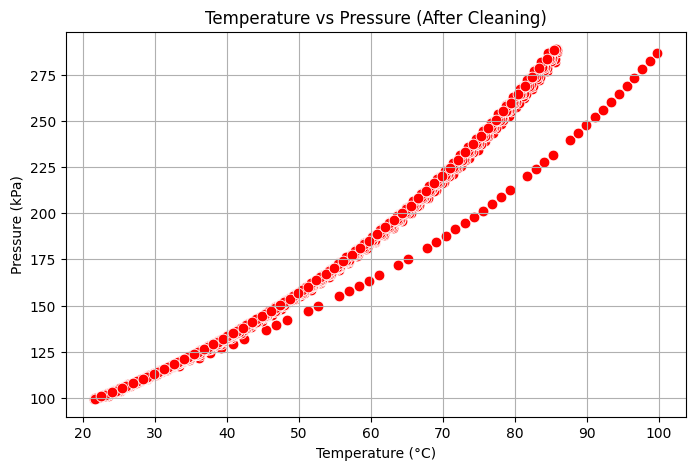

In [ ]:
# Visualization to verify

plt.figure(figsize=(8,5))
sns.scatterplot(x='Temperature', y='Pressure', data=df, color='red', s=60)
plt.title("Temperature vs Pressure (After Cleaning)")
plt.xlabel("Temperature (°C)")
plt.ylabel("Pressure (kPa)")
plt.grid(True)
plt.show()

In [ ]:
# To develop a polynomial Regession model that predicts the pressure (kpa) of a gas from its temerature (C)
# visualize how pplynomial regression effectively cature

In [ ]:
# Independent and dependent variables
x = df[['Temperature']].values
y = df['Pressure'].values

In [ ]:
# step : Linear Regreassion (Baseline)

lin_reg = LinearRegression()
lin_reg.fit(x,y)
y_pred_linear = lin_reg.predict(x)
r2_linear = r2_score(y,y_pred_linear)

In [ ]:
# step 4: polynomial Reggresion (Degree 2 and 3)
# Degree 2 (quadractic)

poly2 = PolynomialFeatures(degree=2)
X_poly2 = poly2.fit_transform(x)

poly_reg2 = LinearRegression()
poly_reg2.fit(X_poly2, y)
y_pred_poly2 = poly_reg2.predict(X_poly2)
r2_poly2 = r2_score(y, y_pred_poly2)

In [ ]:
# Degree 3 (Cubic) - optional comparison
poly3 = PolynomialFeatures(degree=3)
X_poly3 = poly3.fit_transform(x)

poly_reg3 = LinearRegression()
poly_reg3.fit(X_poly3, y)
y_pred_poly3 = poly_reg3.predict(X_poly3)
r2_poly3 = r2_score(y, y_pred_poly3)


In [ ]:
# Step 5: Evaluate Models
print("\n Model Performance Comparison:")
print(f"Linear Regression R² Score: {r2_linear:.4f}")
print(f"Polynomial (Degree 2) R² Score: {r2_poly2:.4f}")
print(f"Polynomial (Degree 3) R² Score: {r2_poly3:.4f}")


 Model Performance Comparison:
Linear Regression R² Score: 0.9656
Polynomial (Degree 2) R² Score: 0.9788
Polynomial (Degree 3) R² Score: 0.9815


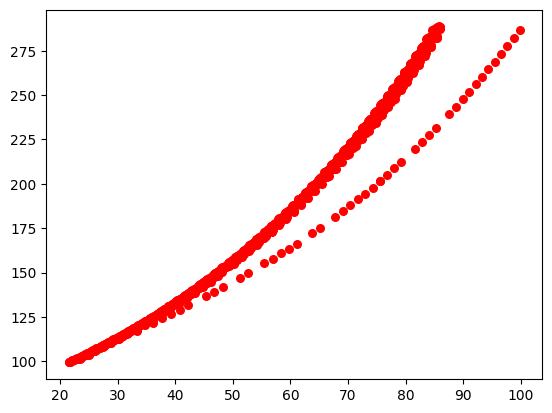

In [ ]:
# Sctter data
plt.scatter(x,y,color='red',label='Actual Data',s=30)

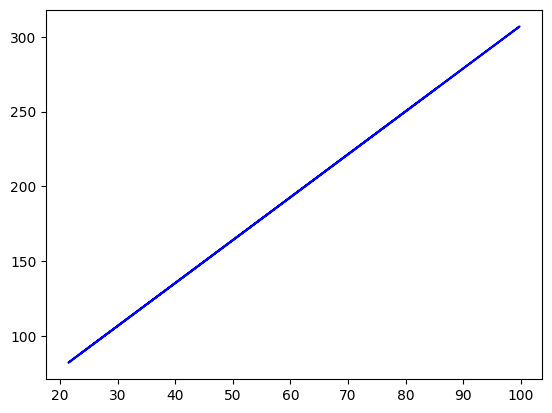

In [ ]:
# Linear Regression line
plt.plot(x,y_pred_linear, color='blue', label=f'Linear Fit (R={r2_linear:.3f}')

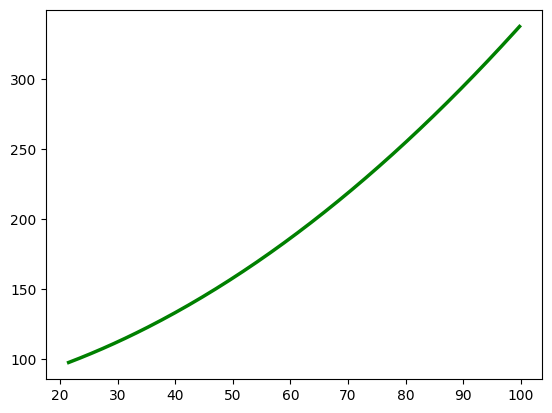

In [ ]:
# Polynomial (Degree 2) curve
x_grid = np.linspace(min(x), max(x), 200).reshape(-1,1)
plt.plot(x_grid, poly_reg2.predict(poly2.transform(x_grid)), color='green', linewidth=2.5,
         label=f'Polynomial (Degree 2) Fit (R²={r2_poly2:.3f})')

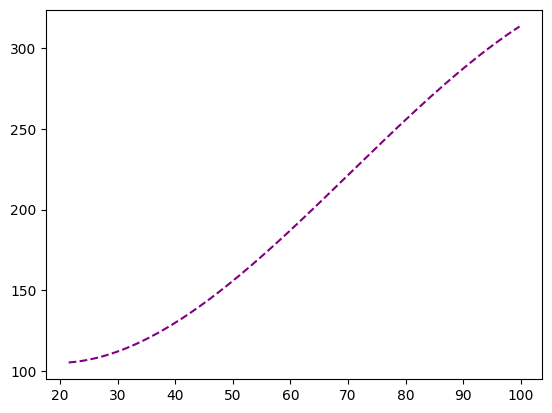

In [ ]:
# Polynomial Degree 3
plt.plot(x_grid, poly_reg3.predict(poly3.transform(x_grid)), color='purple',linestyle='--',
         label=f'Polynomial (Degree 3) Fit (R={r2_poly3:.3f})')

In [ ]:
# Step 7
# Model Evaluation Metrics
# Model Evaluation Metrics
from sklearn.metrics import mean_squared_error

mse_poly2 = mean_squared_error(y, y_pred_poly2)
mse_poly3 = mean_squared_error(y, y_pred_poly3)

print("\nPolynomial Regression Model Details:")
print(f"Degree 2 Coefficients: {poly_reg2.coef_}")
print(f"Degree 2 Intercept: {poly_reg2.intercept_}")
print(f"Degree 2 MSE: {mse_poly2:.4f}")

print(f"\nDegree 3 Coefficients: {poly_reg3.coef_}")
print(f"Degree 3 Intercept: {poly_reg3.intercept_}")
print(f"Degree 3 MSE: {mse_poly3:.4f}")


Polynomial Regression Model Details:
Degree 2 Coefficients: [0.         0.75109167 0.0191053 ]
Degree 2 Intercept: 72.44504465095321
Degree 2 MSE: 63.9803

Degree 3 Coefficients: [ 0.00000000e+00 -3.13591710e+00  9.36357261e-02 -4.42844097e-04]
Degree 3 Intercept: 133.8601628186433
Degree 3 MSE: 55.9758
